In [175]:
import phdthesisplotstyle as phd
import matplotlib.pyplot as plt
import h5py
import numpy as np
from tol_colors import tol_cset, tol_cmap
tolc = tol_cset("bright")
plt.style.use(phd.PHDTHESISPLOTSTYLE)
import glob
import os
from tqdm import tqdm
import awkward as ak

import h5py
import awkward as ak
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from glob import glob
import os
import json

In [176]:
import matplotlib.pyplot as plt
import json
from glob import glob
import dbetto as db

In [177]:
file_string = "runtime_estimates.json"

In [178]:
simple_default = ["physics_list","em","Livermore"]

In [179]:
files = glob("**/" + file_string,recursive=True)

In [180]:
def generate_output(files):
    output = {}
    for file in files:
        folders = file.split("/")
        tmp_output = output
        for folder in folders:
            if folder == "gen":
                continue
            if folder == file_string:
                tmp_output["data"] = json.load(open(file))
            else: 
                if folder not in tmp_output:
                    tmp_output[folder] = {}
                tmp_output = tmp_output[folder]
    return db.AttrsDict(output)

In [181]:
output = generate_output(files)

In [182]:
def iterate_nested_dict(d, parent_key=''):
    for k, v in d.items():
        full_key = f"{parent_key}.{k}" if parent_key else k
        if isinstance(v, dict):
            yield from iterate_nested_dict(v, full_key)
        else:
            yield full_key, v

In [183]:
def generate_project_folders(output):
    project_folders = {}
    for key, value in iterate_nested_dict(output):
        if not "data" in key:
            continue
        folder_list = key.split(".")
        data_idx = folder_list.index("data")
        folder_list = folder_list[:data_idx]
        tmp_dict = project_folders
        for i in range(0,len(folder_list)):
            if i == len(folder_list) - 1:
                tmp_dict[folder_list[i]] = folder_list[-1]
            else:
                if folder_list[i] not in tmp_dict:
                    tmp_dict[folder_list[i]] = {}
                tmp_dict = tmp_dict[folder_list[i]]
    return db.AttrsDict(project_folders)

In [196]:
def draw_project(data,project_list):
    x_labels = []
    for lab in list(data.keys()):
        if "data" in data[lab]:
            x_labels.append(lab)
    x_labels.sort()

    
    y_rate = [data[project]["data"]["event_rate"]["val"] for project in x_labels]
    y_rate_unc = [data[project]["data"]["event_rate"]["std"]/10 for project in x_labels]

    if len(x_labels) == 1:
        x_labels.append("default")
        tmp = output["simple"][project_list[1]]
        for lab in simple_default:
            tmp = tmp[lab]
        y_rate.append(tmp["data"]["event_rate"]["val"])
        y_rate_unc.append(tmp["data"]["event_rate"]["std"])

    fig, ax = plt.subplots(figsize=(phd.figsizes.TextFigure()[0]/6 * len(x_labels),phd.figsizes.TextFigure()[1]))
    ax.errorbar(x_labels,y_rate,yerr=y_rate_unc,fmt='.')
    plt.xticks(rotation=90)
    ax.set_ylabel("Event rate [evts/s]")
    ax.set_title(".".join(project_list))
    ax.set_ylim(0,1.1*max(y_rate))
    ax.set_xlim(-0.5,len(x_labels)-0.5)
    plt.savefig("./figs/" + "_".join(project_list) + ".png",bbox_inches='tight')
    plt.close()

In [197]:
def generate_overview_plots(output):
    project_folders = generate_project_folders(output)
    projects = []
    for key, value in iterate_nested_dict(project_folders):
        lists = key.split(".")
        if lists[:-1] not in projects:
            projects.append(lists[:-1])
    for project in projects:
        tmp_dict = output
        for pr in project:
            tmp_dict = tmp_dict[pr]
        draw_project(tmp_dict,project)
        

In [198]:
generate_overview_plots(output)

In [187]:
a = np.array([68, 66, 68, 65, 67, 65, 67, 67, 67, 67, 65, 65, 65, 67, 67, 65, 65, 65, 67, 67, 66, 65, 65, 65, 66, 66, 67, 65, 65, 65, 66, 65, 65, 65, 65, 66, 65, 65, 65, 66, 66, 65, 67, 65, 65, 67, 65, 66, 68, 66, 65, 67, 67, 67, 66, 67, 67, 67, 67, 67, 66, 65, 66, 67, 65, 66, 65, 69, 66, 66, 69, 70, 65, 66, 66, 65, 66, 67, 65, 66, 66, 66, 68, 70, 67, 65, 69, 68, 71, 70, 70, 68, 68, 70, 68, 68, 68, 70, 67, 68])

In [188]:
b = 2e6/a

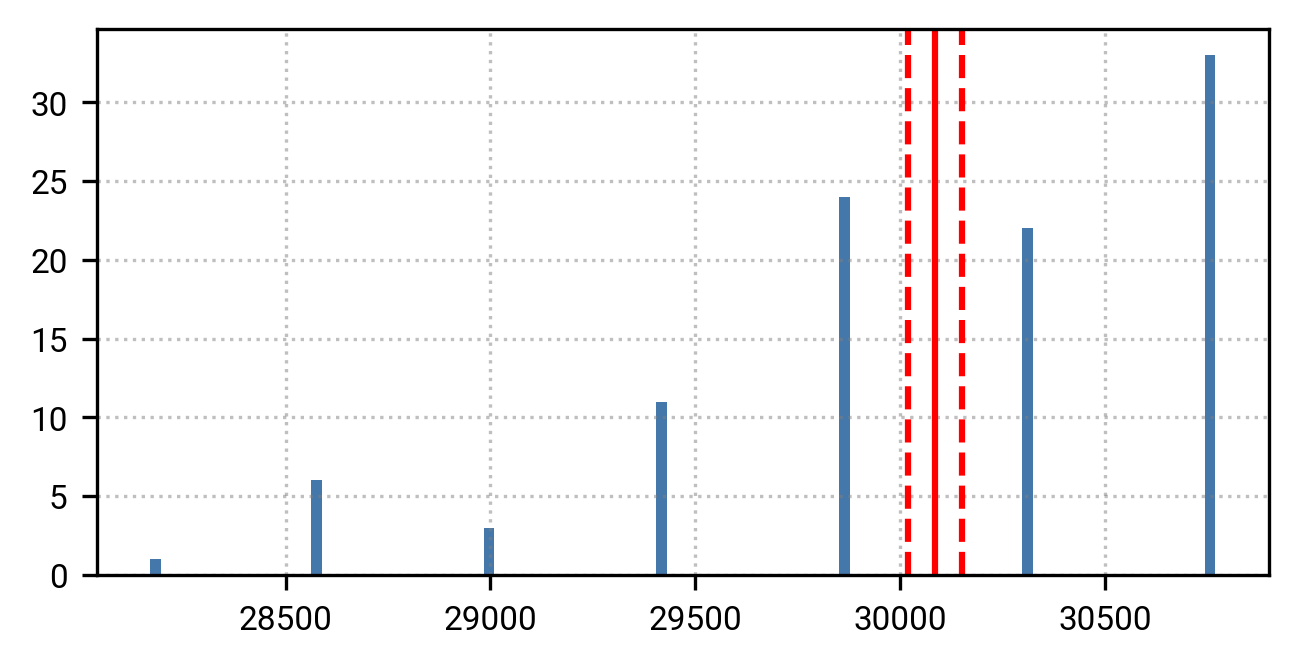

In [195]:
plt.hist(b,bins=np.linspace(np.min(b),np.max(b),100))
plt.axvline(np.mean(b),color='r')
plt.axvline(np.mean(b) + np.std(b)/np.sqrt(len(b)),color='r',linestyle='--')
plt.axvline(np.mean(b) - np.std(b)/np.sqrt(len(b)),color='r',linestyle='--')